# Sanity Check (YOLO Model)

This notebook contains a quick sanity check to ensure the model is able to train as expected using the implementation. It is using a very small subset of the dataset to run and identify issues quickly.

In [1]:
import sys

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import detect

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(detect);

In [4]:
# detect.train_epochs_in(100, None, None, detect.CustomHeadedYolo())

Number of training samples: 11122
Number of validation samples: 3098


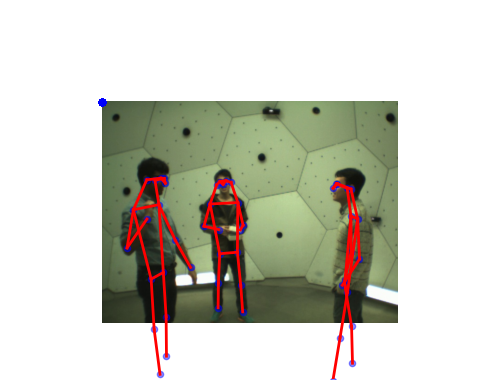

In [5]:
import matplotlib.pyplot as plt

import util
import dataset

data = dataset.YoloDataset("../data/yolo/train")
data_val = dataset.YoloDataset("../data/yolo/val")

print("Number of training samples:", len(data))
print("Number of validation samples:", len(data_val))

img, ann = data[1]
for kp in ann:
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
plt.imshow(img.permute(1, 2, 0))
plt.xlim(-200, 800)
plt.ylim(600, -200)
plt.axis("off")
plt.show()

In [6]:
model = detect.CustomHeadedYolo(path="../nets")
model.train()
x = model(img.unsqueeze(0))

In [7]:
gt = ann.unsqueeze(0)
b = 0

In [8]:
detect.compute_loss(x, gt, model)

In [9]:
anchors = model.base_net.model[-1].anchors
strides = model.base_net.model[-1].strides

In [10]:
strides

tensor([[ 8.,  8.,  8.,  ..., 32., 32., 32.]])

In [ ]:
strides.shape

torch.Size([1, 6300])

In [ ]:
import torch

valid = x["one2one"]["scores"].detach() > 0
all_kpts = x["one2one"]["kpts"].detach()
all_kpts = all_kpts.view(all_kpts.shape[0], 17, 3, -1)
all_kpts[:, :, :2] = (all_kpts[:, :, :2] + anchors) * strides
kpts = all_kpts[:, :, :, valid.flatten()]

In [ ]:
kpts.shape

torch.Size([1, 17, 3, 3])

In [ ]:
b_kpts = kpts[b].permute(2, 0, 1)
b_gt = gt[b]

In [ ]:
dist_matrix = b_kpts[:, :, :2].unsqueeze(1) - b_gt[:, :, :2].unsqueeze(0)
dist_matrix *= dist_matrix
weight = torch.sigmoid(b_kpts[:, :, 2]).unsqueeze(1) * b_gt[:, :, 2].unsqueeze(0)
cost_matrix = torch.sum(torch.sum(dist_matrix, dim=-1) * weight, dim=-1) / (torch.sum(weight, dim=-1) + 1e-5)

In [ ]:
cost_matrix

tensor([[2.0766e+32, 2.0808e+32, 2.0262e+32, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.3191e+32, 1.2853e+32, 1.2580e+32, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [4.8959e+32, 4.8421e+32, 4.8304e+32, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]])

In [ ]:
import scipy.optimize

cost_np = cost_matrix.cpu().numpy()
_, col_ind = scipy.optimize.linear_sum_assignment(cost_np)
det_idx = torch.tensor(col_ind, dtype=torch.long, device=kpts.device)

In [ ]:
indices[b, 0, det_idx]

tensor([6194, 6108, 6239])